# EDA NOTEBOOK

## I. Introduction and Setup

### 1. Introduction

**Notebook này thực hiện Exploratory Data Analysis (EDA)** trên bộ dữ liệu 
[UCI Heart Disease Dataset] để hiểu sâu về cấu trúc dữ liệu
, phân phối của các đặc trưng, mối tương quan giữa các biến,
và các vấn đề cần xử lý trước khi xây dựng mô hình.

### 2. EDA Roadmap

| Bước | Nội dung | Người thực hiện |
|------|----------|-----------------|
| I | Introduction & Setup | Cả nhóm |
| II | Target Analysis | Quyên |
| III | Categorical Analysis | Quyên |
| IV | Distribution Analysis | Phát |
| V | Correlation Analysis | Phát |
| VI | Outlier Detection | Xuyên |
| VII | Statistical Tests | Xuyên |
| VIII | Key Findings | Cả nhóm |

### 3. Environment Setup and Library Import

In [16]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from scipy import stats

#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv 
    Args:
        dataset_path (str): đường dẫn file csv 
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None
    
    try: 
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None
    
#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

Đã tải dữ liệu thành công!


### 4. Data Overview
Đây là tập dữ liệu thô được lấy từ nguồn **[UCI Heart Disease Dataset]**
Link: https://archive.ics.uci.edu/dataset/45/heart+disease

In [4]:
#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.


In [5]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()

- Các thông tin cơ bản:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê:")
df.describe()

- Các thông tin thống kê:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [10]:
#5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


II. Exploratory Data Analysis (EDA)

### V. Outlier-Analysis
- Mục tiêu: phát hiện các giá trị bất thường (outliers) trong dataset. Outliers có thể:  dữ liệu thật (bệnh nhân có chỉ số rất cao) hay lỗi nhập liệu / dữ liệu thiếu. Nếu không kiểm tra outlier, các giá trị cực đoan có thể ảnh hưởng đến việc phân tích thống kê và mô hình machine learning.

- Các biến y tế như: age, trestbps, chol, thalch , oldpeak . Có thể chứa các giá trị cực đoan hoặc lỗi nhập liệu. Nếu không phát hiện các giá trị này, chúng có thể làm **sai lệch kết quả phân tích thống kê và mô hình machine learning**. Vì vậy cần thực hiện **Outlier Analysis** trước khi tiếp tục các bước tiếp theo.

In [24]:
# các biến số liên tục cần kiểm tra outlier
columns = ["age", "trestbps", "chol", "thalch", "oldpeak"]

columns

['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [26]:
# Hàm vẽ Boxplot :  Boxplot giúp trực quan hóa phân bố dữ liệu và dễ dàng nhận ra các điểm nằm ngoài phạm vi bình thường.
def plot_boxplot(df, column):

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [31]:
# Phát hiện Outlier bằng phương pháp IQR : Phương pháp **Interquartile Range (IQR)** được sử dụng để xác định các giá trị bất thường.
def detect_outlier(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\n===== Outlier in {column} =====")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))

    return outliers


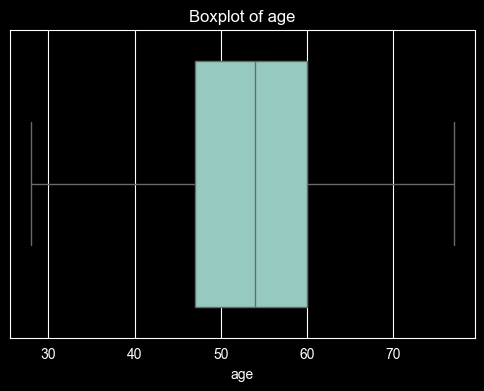


===== Outlier in age =====
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0


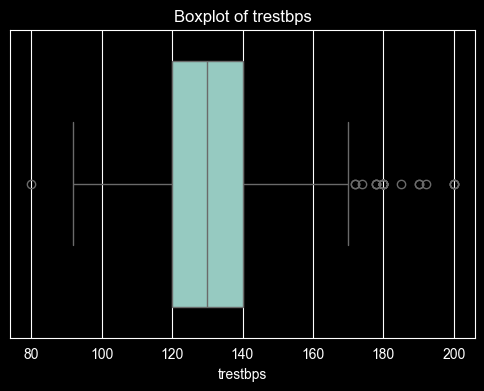


===== Outlier in trestbps =====
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 27


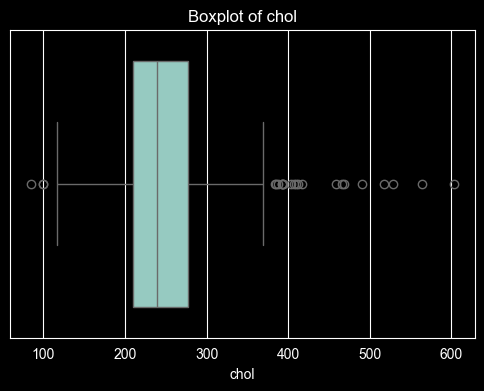


===== Outlier in chol =====
Lower bound: 109.875
Upper bound: 376.875
Number of outliers: 23


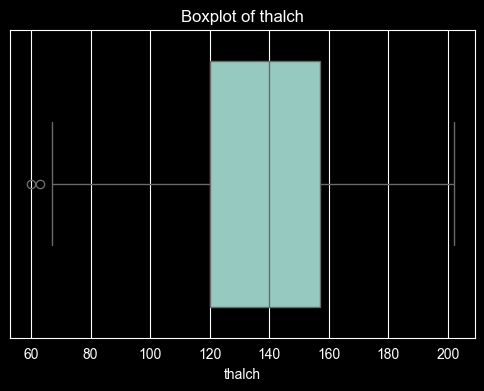


===== Outlier in thalch =====
Lower bound: 64.5
Upper bound: 212.5
Number of outliers: 2


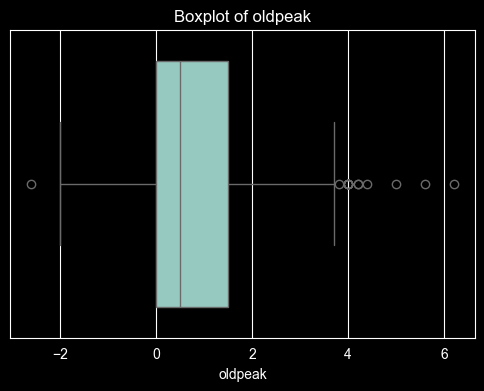


===== Outlier in oldpeak =====
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16


In [32]:
# Phân tích Outlier cho từng biến:  Vẽ boxplot và Tính số lượng outlier bằng IQR
for col in columns:
    plot_boxplot(df, col)
    detect_outlier(df, col)

In [34]:
# Kiểm tra giá trị cực trị (Min và Max): Sau khi phát hiện outlier, chúng ta cần kiểm tra **giá trị nhỏ nhất và lớn nhất** để xác định: Outlier là dữ liệu thật hay lỗi nhập liệu
for col in ["age", "trestbps", "chol", "thalch", "oldpeak"]:
    print(f"\nColumn: {col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Column: age
Min: 28
Max: 77

Column: trestbps
Min: 80.0
Max: 200.0

Column: chol
Min: 85.0
Max: 603.0

Column: thalch
Min: 60.0
Max: 202.0

Column: oldpeak
Min: -2.6
Max: 6.2


 Nhận xét Outlier:
Kết quả cho thấy:
Cholesterol có nhiều outlier hơn các biến khác.
Một số giá trị như chol = 0 hoặc trestbps = 0 không hợp lý về mặt y học.

Ví dụ:
- Cholesterol không thể bằng 0
- Huyết áp không thể bằng 0

Do đó các giá trị này có thể là lỗi nhập liệu hoặc missing values.

Xử lý dữ liệu bất thường các giá trị bằng 0 trong các cột: "age", "trestbps", "chol", "thalch", "oldpeak". Được xem là dữ liệu không hợp lệ. Thay vì xóa dữ liệu, chúng ta chuyển các giá trị này thành missing values (NaN) để xử lý ở bước preprocessing.


In [48]:
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)

Kết luận Outlier Analysis :Phân tích outlier cho thấy dataset chứa một số giá trị bất thường. Một số giá trị như:

- chol = 0
- trestbps = 0

được xác định là lỗi dữ liệu và được chuyển thành missing values. Các giá trị cực cao nhưng vẫn hợp lý về mặt y học sẽ được giữ lại để đảm bảo không làm mất thông tin quan trọng trong dataset.

### VI.Statistical Tests (Kiểm định thống kê)

Mục tiêu: Sau khi khám phá dữ liệu (EDA) và phân tích outlier, bước tiếp theo là thực hiện kiểm định thống kê để xem liệu một số biến có liên quan đến bệnh tim hay không. Trong dataset này, biến `num` thể hiện tình trạng bệnh tim:

- `0` : không có bệnh tim
- `1,2,3,4` : có bệnh tim

Để đơn giản hóa phân tích, chúng ta chuyển biến này thành biến nhị phân:

- `0` : không bệnh
- `1` : có bệnh

Sau đó kiểm định xem tuổi (age) có khác biệt giữa hai nhóm này hay không.

Chuẩn hóa biến bệnh tim : Biến `num` có nhiều mức (0–4).  Chúng ta chuyển thành biến nhị phân `disease`:

- 0 → không bệnh
- Lớn hơn 0 → có bệnh

In [44]:
df["disease"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

df["disease"].value_counts()

disease
1    509
0    411
Name: count, dtype: int64

Tách dữ liệu thành hai nhóm:
Để thực hiện kiểm định thống kê, chúng ta chia dữ liệu thành: Nhóm có bệnh tim và  Nhóm không có bệnh tim.
Sau đó so sánh biến age giữa hai nhóm này

In [40]:
group_disease = df[df["disease"] == 1]["age"]
group_no_disease = df[df["disease"] == 0]["age"]

print("Số bệnh nhân có bệnh tim:", len(group_disease))
print("Số bệnh nhân không bệnh tim:", len(group_no_disease))

Số bệnh nhân có bệnh tim: 509
Số bệnh nhân không bệnh tim: 411


Chọn phương pháp kiểm định: Dữ liệu y tế thường không tuân theo phân phối chuẩn. Vì vậy thay vì dùng T-test, chúng ta sử dụng:Mann–Whitney U Test Đây là kiểm định phi tham số dùng để so sánh hai nhóm độc lập.

In [42]:
stat, p_value = stats.mannwhitneyu(group_disease, group_no_disease)

print("Statistic:", stat)
print("P-value:", p_value)

Statistic: 139869.0
P-value: 1.288873276620284e-18


 Giả thuyết kiểm định:
 H0 (Null Hypothesis):Không có sự khác biệt về tuổi giữa nhóm có bệnh tim và không bệnh tim.
 H1 (Alternative Hypothesis): Có sự khác biệt về tuổi giữa hai nhóm.

In [43]:
alpha = 0.05

print("\n===== Kết luận =====")

if p_value < alpha:
    print("Bác bỏ H0")
    print("→ Tuổi có ảnh hưởng đến nguy cơ bệnh tim")
else:
    print("Không đủ bằng chứng để bác bỏ H0")


===== Kết luận =====
Bác bỏ H0
→ Tuổi có ảnh hưởng đến nguy cơ bệnh tim


Nhận xét:
 Kết quả kiểm định cho thấy liệu tuổi có liên quan đến bệnh tim hay không.
  Nếu p-value < 0.05:
  → Có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.
  Điều này cho thấy tuổi có thể là một yếu tố liên quan đến nguy cơ mắc bệnh tim.
Ngược lại nếu p-value ≥ 0.05:
→ Không có đủ bằng chứng thống kê để kết luận tuổi ảnh hưởng đến bệnh tim.